# Characterizing Bolide Signatures in GOES GLM Level-2 Data

**CEWA 567 Final Project — Xueyicheng Xu**

AI usage claim: This notebook uses Claude for script/code organization. Besides, AI was also used to help with data visualization and API calling for data download. The research, including literature search and study, stats pipeline design, and physics conclusions, are all done by Xueyicheng Xu.

## 1. Setup


In [52]:
import os, glob, re, warnings, requests, io
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


In [53]:
# config — EDIT DATA_ROOT
DATA_ROOT = "Z:/"

WINDOW_MINUTES = 2
SPATIAL_RADIUS_DEG = 2.0
CONTROL_OFFSETS_HR = [-2, -1, 1, 2, 3]
NEOBOLIDE_API = "https://neo-bolide.ndc.nasa.gov/service/event/public"

FEATURE_COLS = ['n_groups','duration_s','spatial_extent_km','line_fit_residual',
                'max_group_line_dist','energy_balance_frac','peak_energy_ratio',
                'total_energy_J','light_curve_smoothness','mean_speed_km_s']


### Utility functions


In [54]:
# file finder + NetCDF parser (for local GLM L2 data)
def parse_filename_times(fname):
    parts = fname.split('_')
    def _p(t):
        base = datetime(int(t[0:4]),1,1) + timedelta(days=int(t[4:7])-1)
        return base.replace(hour=int(t[7:9]),minute=int(t[9:11]),
                            second=int(t[11:13]),microsecond=int(t[13])*100000)
    return _p(parts[3][1:]), _p(parts[4][1:])

def find_glm_files(dt_center, window_min=WINDOW_MINUTES):
    dt_s = dt_center - timedelta(minutes=window_min)
    dt_e = dt_center + timedelta(minutes=window_min)
    dirs = set()
    t = dt_s
    while t <= dt_e:
        dirs.add((t.year, t.timetuple().tm_yday, t.hour)); t += timedelta(hours=1)
    dirs.add((dt_e.year, dt_e.timetuple().tm_yday, dt_e.hour))
    out = []
    for y,d,h in dirs:
        dp = os.path.join(DATA_ROOT, f"Lightning-{y}", f"{d:03d}", f"{h:02d}")
        if os.path.isdir(dp):
            out.extend(glob.glob(os.path.join(dp, "OR_GLM-L2-LCFA_G16_*.nc")))
    matched = []
    for fp in out:
        try:
            fs, fe = parse_filename_times(os.path.basename(fp))
            if fs <= dt_e and fe >= dt_s: matched.append(fp)
        except: pass
    return sorted(matched)

def parse_glm_groups(filepaths):
    frames = []
    for fp in filepaths:
        try: ds = xr.open_dataset(fp)
        except: continue
        if ds.dims.get('number_of_groups',0)==0: ds.close(); continue
        raw = ds['group_time_offset'].values
        if np.issubdtype(raw.dtype, np.datetime64):
            times = pd.DatetimeIndex(raw)
        elif np.issubdtype(raw.dtype, np.timedelta64):
            try: pt = pd.Timestamp(ds.attrs.get('time_coverage_start'))
            except: pt = pd.Timestamp(parse_filename_times(os.path.basename(fp))[0])
            times = pt + pd.to_timedelta(raw)
        else:
            try: pt = pd.Timestamp(ds.attrs.get('time_coverage_start'))
            except: pt = pd.Timestamp(parse_filename_times(os.path.basename(fp))[0])
            times = pt + pd.to_timedelta(raw, unit='s')
        frames.append(pd.DataFrame({'time':times,'lat':ds['group_lat'].values,
            'lon':ds['group_lon'].values,'energy':ds['group_energy'].values}))
        ds.close()
    if not frames: return pd.DataFrame(columns=['time','lat','lon','energy'])
    return pd.concat(frames,ignore_index=True).sort_values('time').reset_index(drop=True)


In [55]:
# spatial filter
def filter_spatial(df, clat, clon, radius=SPATIAL_RADIUS_DEG):
    m = (df['lat']>=clat-radius)&(df['lat']<=clat+radius)&(df['lon']>=clon-radius)&(df['lon']<=clon+radius)
    return df[m].copy().reset_index(drop=True)

# clustering (Rumpf 2019 thresholds)
def cluster_groups(df, t_gap=0.33, s_gap=0.35):
    df = df.sort_values('time').reset_index(drop=True)
    cids = np.zeros(len(df), dtype=int); cur = 0
    for i in range(1, len(df)):
        dt = (df.loc[i,'time']-df.loc[i-1,'time']).total_seconds()
        if dt>t_gap or abs(df.loc[i,'lat']-df.loc[i-1,'lat'])>s_gap or abs(df.loc[i,'lon']-df.loc[i-1,'lon'])>s_gap:
            cur += 1
        cids[i] = cur
    df = df.copy(); df['cluster_id'] = cids; return df

# trim spatial outliers using MAD
def trim_outliers(df, sigma=2.5):
    if len(df) < 5: return df
    lats, lons = df['lat'].values, df['lon'].values
    coords = np.column_stack([lons-lons.mean(), lats-lats.mean()])
    perp = np.linalg.eigh(np.cov(coords.T))[1][:,0]
    dists = np.abs(coords @ perp)
    med = np.median(dists); mad = np.median(np.abs(dists-med))*1.4826
    if mad < 1e-10: return df
    return df[dists < med + sigma*mad].copy().reset_index(drop=True)

# pick largest cluster
def largest_cluster(df_c, min_n=3):
    if df_c.empty: return None
    counts = df_c['cluster_id'].value_counts()
    valid = counts[counts>=min_n]
    if valid.empty: return None
    result = df_c[df_c['cluster_id']==valid.idxmax()].copy()
    return trim_outliers(result)


In [56]:
# haversine distance
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1,lon1,lat2,lon2 = map(np.radians,[lat1,lon1,lat2,lon2])
    dlat=lat2-lat1; dlon=lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R*2*np.arcsin(np.sqrt(a))

# feature extraction
def extract_features(df_cluster):
    feat = {}; n = len(df_cluster); feat['n_groups'] = n
    if n < 3:
        for k in FEATURE_COLS[1:]: feat[k] = np.nan
        return feat
    df = df_cluster.sort_values('time').reset_index(drop=True)
    lats, lons, energies = df['lat'].values, df['lon'].values, df['energy'].values
    times = df['time']
    duration = (times.iloc[-1]-times.iloc[0]).total_seconds(); feat['duration_s'] = duration
    # spatial extent
    if n <= 200:
        mx = max(haversine_km(lats[i],lons[i],lats[j],lons[j]) for i in range(n) for j in range(i+1,n))
    else:
        mx = max(haversine_km(lats.min(),lons.min(),lats.max(),lons.max()),
                 haversine_km(lats.min(),lons.max(),lats.max(),lons.min()))
    feat['spatial_extent_km'] = mx
    # line fit (PCA)
    lc, la = lons-lons.mean(), lats-lats.mean()
    if np.std(lc)<1e-10 and np.std(la)<1e-10:
        feat['line_fit_residual']=0; feat['max_group_line_dist']=0
    else:
        coords = np.column_stack([lc,la])
        perp = np.linalg.eigh(np.cov(coords.T))[1][:,0]
        dists = np.abs(coords @ perp)
        feat['line_fit_residual'] = np.mean(dists**2)
        span = max(lats.max()-lats.min(),lons.max()-lons.min())
        feat['max_group_line_dist'] = np.max(dists)/span if span>1e-10 else 0
    # energy
    total = energies.sum(); feat['total_energy_J'] = total
    if total>0 and duration>0:
        hi = min(np.searchsorted(np.cumsum(energies),total/2),n-1)
        feat['energy_balance_frac'] = (times.iloc[hi]-times.iloc[0]).total_seconds()/duration
    else: feat['energy_balance_frac'] = 0.5
    mn = energies.mean(); feat['peak_energy_ratio'] = energies.max()/mn if mn>0 else 1
    # smoothness
    ws = 5
    if n >= ws:
        ts = (times-times.iloc[0]).dt.total_seconds().values; er = energies.max()-energies.min()
        if er > 0:
            res = []
            for k in range(n-ws+1):
                try:
                    c = np.polyfit(ts[k:k+ws],energies[k:k+ws],3)
                    res.append(np.sum((energies[k:k+ws]-np.polyval(c,ts[k:k+ws]))**2)/er**2)
                except: pass
            feat['light_curve_smoothness'] = np.mean(res) if res else np.nan
        else: feat['light_curve_smoothness'] = 0
    else: feat['light_curve_smoothness'] = np.nan
    feat['mean_speed_km_s'] = mx/duration if duration>0 else 0
    return feat


In [57]:
# plot helpers
def plot_trace(df, ax, title='', color='red', show_fit=True):
    df = df.sort_values('time').reset_index(drop=True)
    lats, lons = df['lat'].values, df['lon'].values
    times = (df['time']-df['time'].iloc[0]).dt.total_seconds().values
    energies = df['energy'].values
    span = max(lats.max()-lats.min(), lons.max()-lons.min())
    half = 0.05 if span<0.01 else span*1.5+0.02 if span<0.1 else span*0.7
    lc, lo = (lats.min()+lats.max())/2, (lons.min()+lons.max())/2
    ax.set_extent([lo-half,lo+half,lc-half,lc+half], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.OCEAN, facecolor='#e6f2ff')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.gridlines(draw_labels={'left':True,'bottom':True,'right':False,'top':False},
                 linewidth=0.3, alpha=0.4, x_inline=False, y_inline=False)
    ax.plot(lons, lats, '-', color='grey', lw=0.6, alpha=0.5, transform=ccrs.PlateCarree())
    en = energies/energies.max() if energies.max()>0 else energies
    sc = ax.scatter(lons, lats, c=times, s=15+80*en, cmap='plasma',
                    edgecolors='k', linewidths=0.3, transform=ccrs.PlateCarree(), zorder=5)
    plt.colorbar(sc, ax=ax, shrink=0.5, pad=0.10, label='Time (s)')
    if show_fit and len(df)>=3:
        coords = np.column_stack([lons-lons.mean(),lats-lats.mean()])
        _,ev = np.linalg.eigh(np.cov(coords.T)); d=ev[:,1]; pr=coords@d
        p1 = np.array([lons.mean(),lats.mean()])+pr.min()*1.2*d
        p2 = np.array([lons.mean(),lats.mean()])+pr.max()*1.2*d
        ax.plot([p1[0],p2[0]],[p1[1],p2[1]],'k--',lw=1,alpha=0.5,transform=ccrs.PlateCarree(),label='Best-fit line')
        ax.legend(fontsize=6, loc='upper left')
    dur = times[-1] if len(times)>1 else 0
    ax.set_title(title, fontsize=10)
    ax.text(0.02,0.02,f'{len(df)} groups | {dur:.2f}s',transform=ax.transAxes,fontsize=7,va='bottom',
            bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.8))

def plot_lightcurve(df, ax, title=''):
    df = df.sort_values('time').reset_index(drop=True)
    ts = (df['time']-df['time'].iloc[0]).dt.total_seconds().values
    e = df['energy'].values
    dur = ts[-1]-ts[0] if len(ts)>1 else 0
    if dur < 1: tp = ts*1000; unit='ms'
    else: tp = ts; unit='s'
    ax.scatter(tp, e, c=ts, s=15, cmap='plasma', edgecolors='k', linewidths=0.2, zorder=5)
    ax.plot(tp, e, 'k-', lw=0.4, alpha=0.3)
    tot = e.sum()
    if tot>0:
        hi = min(np.searchsorted(np.cumsum(e),tot/2),len(df)-1)
        ax.axvline(tp[hi],color='grey',ls=':',lw=1,label=f'50% energy @ {tp[hi]:.1f}{unit}')
        ax.legend(fontsize=7)
    ax.set_xlabel(f'Time ({unit})'); ax.set_ylabel('Energy (J)')
    ax.set_title(title, fontsize=10)


In [58]:
# NEO-Bolide API
def fetch_neobolide_catalog():
    resp = requests.get(NEOBOLIDE_API); resp.raise_for_status()
    rows = []
    for evt in resp.json()['data']:
        dt = pd.Timestamp(evt['datetime'], unit='ms', tz='UTC').tz_localize(None)
        gt_cat = ''
        for v in evt.get('groundTrack',{}).values():
            if isinstance(v,dict): gt_cat=v.get('category',''); break
        pe = np.nan
        for v in evt.get('brightness',{}).values():
            if isinstance(v,dict) and 'value' in v:
                val = v.get('value')
                if val is not None and (np.isnan(pe) or val>pe): pe=val
        ncf, alat, alon = None, np.nan, np.nan
        for att in evt.get('attachments',[]):
            if att.get('platformId')=='G16':
                fns = att.get('netCdfFilename',[])
                if fns: ncf=fns[0]
                coords = att.get('location',{}).get('coordinates',[])
                if len(coords)==2: alon,alat=coords[0],coords[1]
                break
        rows.append({'event_id':evt['_id'],'datetime':dt,'lat':evt.get('latitude',np.nan),
                     'lon':evt.get('longitude',np.nan),'att_lat':alat,'att_lon':alon,
                     'duration':evt.get('duration',np.nan),'detected_by':evt.get('detectedBy',''),
                     'ground_track':gt_cat,'confidence':evt.get('confidenceRating',''),
                     'peak_energy':pe,'ncf_g16':ncf})
    return pd.DataFrame(rows)

# load bolide from local NetCDF using NEO-Bolide filename
def load_bolide_local(ncf, blat, blon):
    fs, fe = parse_filename_times(ncf)
    y, d, h = fs.year, fs.timetuple().tm_yday, fs.hour
    lp = os.path.join(DATA_ROOT, f"Lightning-{y}", f"{d:03d}", f"{h:02d}", ncf)
    if not os.path.exists(lp): return None
    files = find_glm_files(fs + (fe-fs)/2, window_min=1)
    if not files: files = [lp]
    df = parse_glm_groups(files)
    if df.empty: return None
    for r in [SPATIAL_RADIUS_DEG, 3.0, 5.0]:
        df_f = filter_spatial(df, blat, blon, radius=r)
        if not df_f.empty: break
    if df_f.empty: return None
    df_c = cluster_groups(df_f)
    stats = df_c.groupby('cluster_id').agg(n=('lat','count'),mt=('time','median'))
    valid = stats[stats['n']>=3].copy()
    if valid.empty: return None
    valid['off'] = abs(valid['mt']-pd.Timestamp(fs))
    best = valid['off'].idxmin()
    result = trim_outliers(df_c[df_c['cluster_id']==best].copy())
    if len(result)<3: return None
    return result.drop(columns=['cluster_id'],errors='ignore').reset_index(drop=True)

# lightning control extraction
def extract_control(dt, lat, lon):
    files = find_glm_files(dt)
    if not files: return None, None
    df = parse_glm_groups(files)
    if df.empty: return None, None
    for r in [SPATIAL_RADIUS_DEG, 3.0, 5.0, 10.0]:
        df_f = filter_spatial(df, lat, lon, radius=r)
        if not df_f.empty: break
    if df_f.empty: return None, None
    sel = largest_cluster(cluster_groups(df_f))
    if sel is None: return None, None
    feat = extract_features(sel)
    feat['background_groups'] = len(df_f)
    return feat, sel


---
## 2. Bolide Catalog


In [59]:
# fetch from NEO-Bolide
df_catalog = fetch_neobolide_catalog()
print(f'Total detections: {len(df_catalog)}')


Total detections: 10665


In [60]:
# filter to GOES-16 2018-2024 with NetCDF filenames
df_g16 = df_catalog[
    (df_catalog['detected_by'].str.contains('GLM-16',na=False)) &
    (df_catalog['datetime']>='2018-01-01') &
    (df_catalog['datetime']<='2024-12-31') &
    (df_catalog['ncf_g16'].notna())
].copy().reset_index(drop=True)
print(f'GOES-16 with NetCDF: {len(df_g16)}')


GOES-16 with NetCDF: 5035


In [61]:
# filter near land
from shapely.geometry import Point
from shapely.ops import unary_union
import cartopy.io.shapereader as shpreader

shp = shpreader.natural_earth(resolution='110m', category='physical', name='land')
land_buf = unary_union(list(shpreader.Reader(shp).geometries())).buffer(3.0)
df_land = df_g16[[land_buf.contains(Point(r['lon'],r['lat'])) for _,r in df_g16.iterrows()]].reset_index(drop=True)
print(f'Near land: {len(df_land)}')


Near land: 1906


In [62]:
# select 30 stratified by energy
df_sel = df_land.dropna(subset=['peak_energy']).copy()
df_sel = df_sel[df_sel['peak_energy']>0].copy()
df_sel['energy_tier'] = pd.qcut(df_sel['peak_energy'], q=3, labels=['low','mid','high'])
catalog = pd.concat([df_sel[df_sel['energy_tier']==t].sample(n=min(10,len(df_sel[df_sel['energy_tier']==t])),random_state=42) for t in ['low','mid','high']])
catalog = catalog.sort_values('datetime').reset_index(drop=True)
catalog['eid'] = [f'B{i:03d}' for i in range(len(catalog))]
print(f'Selected {len(catalog)} events')
catalog['energy_tier'].value_counts()


Selected 30 events


energy_tier
low     10
mid     10
high    10
Name: count, dtype: int64

In [63]:
# load bolide data from local NetCDF (ms timing)
bolide_data = {}
for _, row in catalog.iterrows():
    eid = row['eid']
    ncf = row['ncf_g16']
    blat = row['att_lat'] if not np.isnan(row['att_lat']) else row['lat']
    blon = row['att_lon'] if not np.isnan(row['att_lon']) else row['lon']
    df_lc = load_bolide_local(ncf, blat, blon)
    if df_lc is not None and len(df_lc)>=3:
        dur = (df_lc['time'].max()-df_lc['time'].min()).total_seconds()
        bolide_data[eid] = df_lc
        print(f'  {eid}: {len(df_lc)} groups, {dur*1000:.0f} ms')
    else:
        print(f'  {eid}: failed')
print(f'\nLoaded: {len(bolide_data)}/{len(catalog)}')


  B000: 17 groups, 36 ms
  B001: 219 groups, 560 ms
  B002: 15 groups, 219 ms
  B003: 40 groups, 82 ms
  B004: 34 groups, 97 ms
  B005: 74 groups, 145 ms
  B006: 36 groups, 72 ms
  B007: 44 groups, 109 ms
  B008: 23 groups, 46 ms
  B009: 45 groups, 89 ms
  B010: 35 groups, 68 ms
  B011: 82 groups, 169 ms
  B012: 27 groups, 78 ms
  B013: 37 groups, 72 ms
  B014: 29 groups, 56 ms
  B015: 111 groups, 425 ms
  B016: 95 groups, 250 ms
  B017: 41 groups, 99 ms
  B018: 22 groups, 42 ms
  B019: 25 groups, 53 ms
  B020: 20 groups, 51 ms
  B021: 64 groups, 195 ms
  B022: 20 groups, 42 ms
  B023: 22 groups, 46 ms
  B024: 82 groups, 179 ms
  B025: 44 groups, 46 ms
  B026: 18 groups, 48 ms
  B027: 37 groups, 71 ms
  B028: 90 groups, 213 ms
  B029: 32 groups, 74 ms

Loaded: 30/30


In [64]:
# compute bolide features
bolide_features = []
for _, row in catalog.iterrows():
    eid = row['eid']
    if eid not in bolide_data: continue
    feat = extract_features(bolide_data[eid])
    feat['event_id'] = eid; feat['label'] = 'bolide'; feat['energy_tier'] = row['energy_tier']
    bolide_features.append(feat)
df_bolide = pd.DataFrame(bolide_features)
df_bolide[FEATURE_COLS].describe().round(4)


,n_groups,duration_s,spatial_extent_km,line_fit_residual,max_group_line_dist,energy_balance_frac,peak_energy_ratio,total_energy_J,light_curve_smoothness,mean_speed_km_s
count,30.0000,30.0000,30.0000,30.0,30.0000,30.0000,30.0000,30.0,30.0000,30.0000
mean,49.3333,0.1244,6.0568,0.0,0.0625,0.5309,1.9007,0.0,0.0112,59.6506
std,41.2564,0.1183,7.4532,0.0,0.1451,0.1687,0.7497,0.0,0.0192,113.4181
min,15.0000,0.0359,0.0050,0.0,0.0000,0.0646,1.2871,0.0,0.0001,0.0916
25%,23.5000,0.0520,0.1350,0.0,0.0017,0.4434,1.4193,0.0,0.0007,1.8667
50%,36.5000,0.0757,6.0622,0.0,0.0109,0.5419,1.6202,0.0,0.0019,27.2698
75%,59.2500,0.1631,8.6704,0.0,0.0199,0.6447,2.0312,0.0,0.0151,54.2272
max,219.0000,0.5604,28.4529,0.0,0.6525,0.8556,4.2461,0.0,0.0910,585.5399


---
## 3. Motivation: Which One is the Meteor?

We scan GLM data from active thunderstorm periods to find lightning clusters
with quasi-linear ground tracks — "imposters" that visually mimic bolides.


In [65]:
# scan for linear lightning clusters
scan_dirs = [(2020,182,20),(2020,182,21),(2020,195,19),(2020,195,20),
             (2021,200,20),(2021,200,21),(2019,210,20),(2019,210,21)]
candidates = []
for y,d,h in scan_dirs:
    dp = os.path.join(DATA_ROOT, f"Lightning-{y}", f"{d:03d}", f"{h:02d}")
    if not os.path.isdir(dp): continue
    ncs = sorted(glob.glob(os.path.join(dp, "OR_GLM-L2-LCFA_G16_*.nc")))[:3]
    if not ncs: continue
    df = parse_glm_groups(ncs)
    if len(df)<50: continue
    for cid, grp in cluster_groups(df).groupby('cluster_id'):
        n = len(grp)
        if n<15 or n>800: continue
        la, lo = grp['lat'].values, grp['lon'].values
        if max(la.max()-la.min(),lo.max()-lo.min())<0.05: continue
        evals = np.linalg.eigvalsh(np.cov(np.column_stack([lo-lo.mean(),la-la.mean()]).T))
        if evals[1]<=0: continue
        candidates.append({'linearity':evals[1]/(evals[0]+1e-15),'n':n,'df':grp.copy()})
candidates.sort(key=lambda x:x['linearity'], reverse=True)
top3 = [f"{c['linearity']:.1f}" for c in candidates[:3]]
print(f'Found {len(candidates)} candidates, top 3 linearity: {top3}')


Found 28 candidates, top 3 linearity: ['6532136.8', '247.2', '218.0']


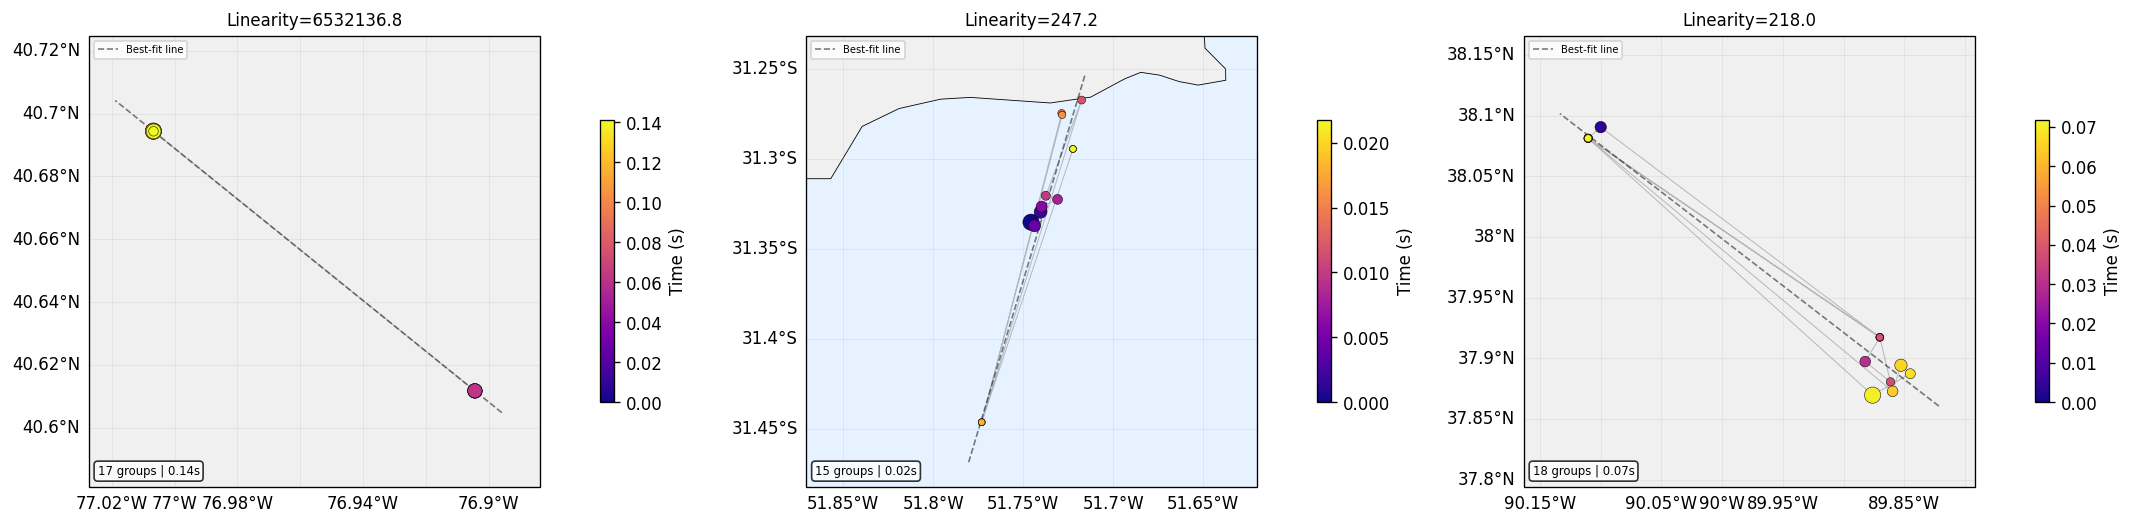

In [66]:
# preview top 3
n_show = min(3, len(candidates))
f, axes = plt.subplots(1, n_show, figsize=(6*n_show,5), subplot_kw={'projection':ccrs.PlateCarree()})
if n_show==1: axes=[axes]
for ax, c in zip(axes, candidates[:n_show]):
    plot_trace(c['df'], ax, title=f"Linearity={c['linearity']:.1f}", color='steelblue')
plt.tight_layout()


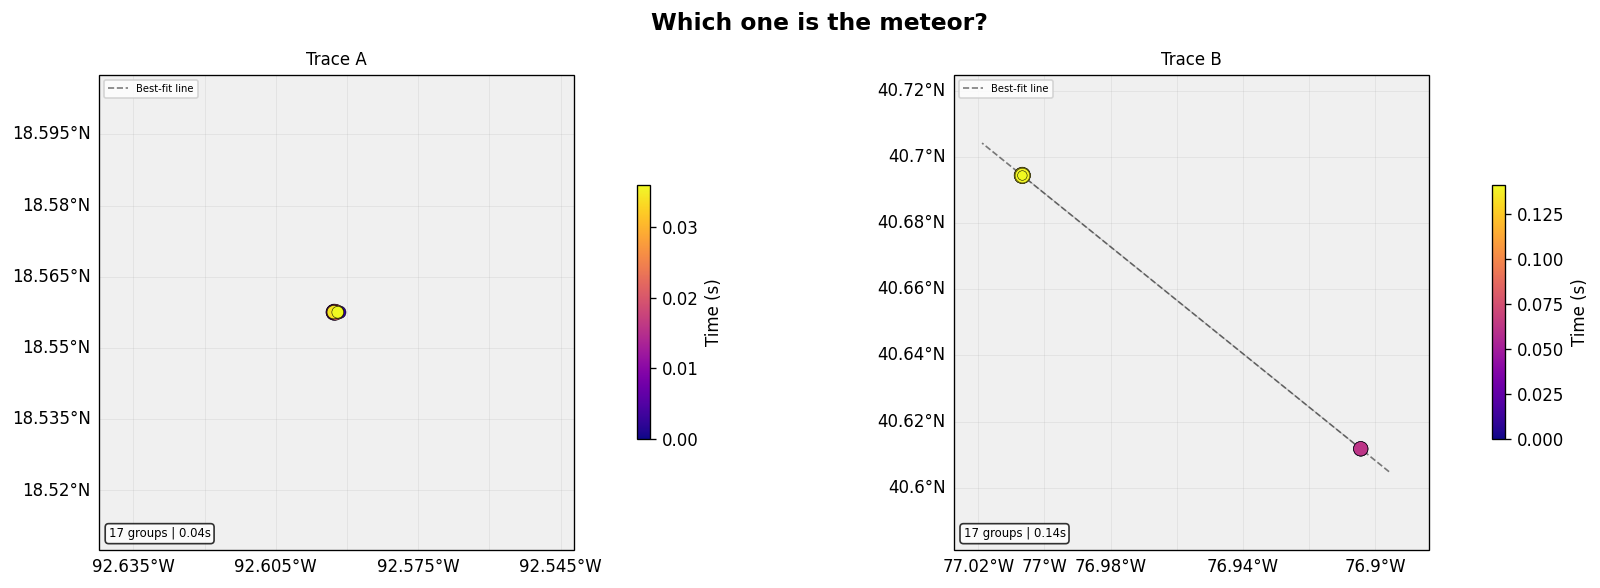

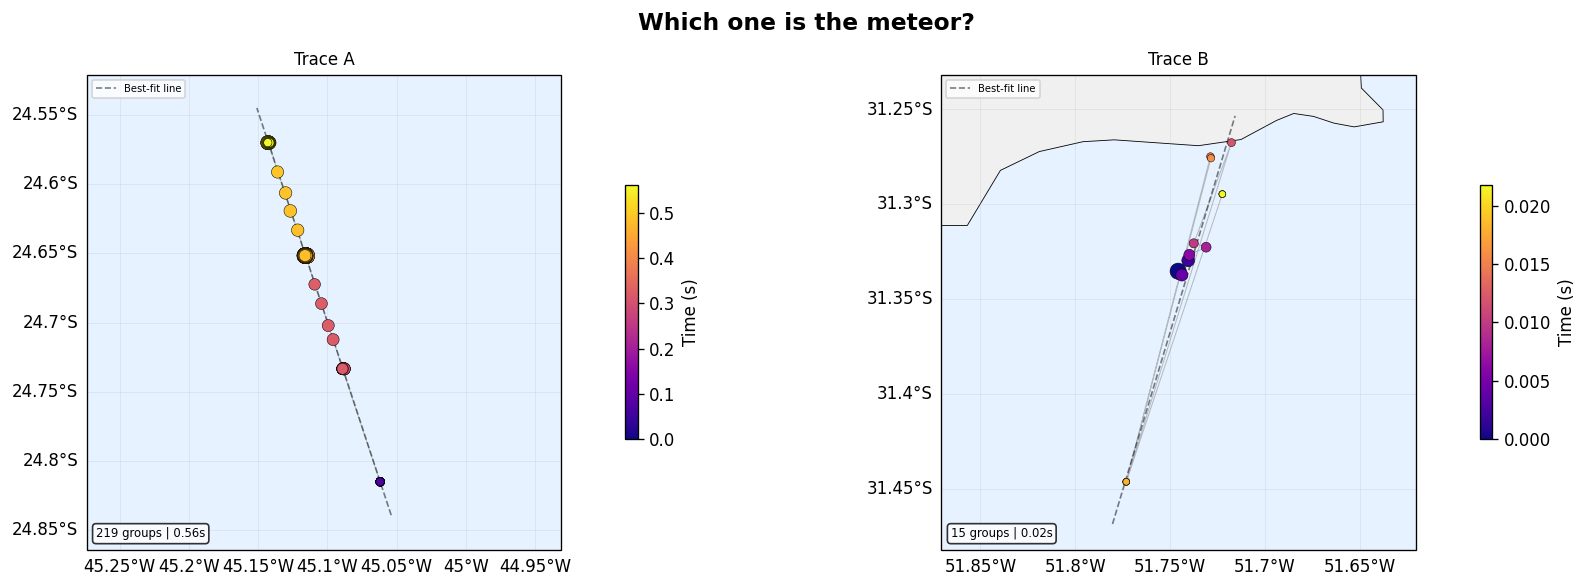

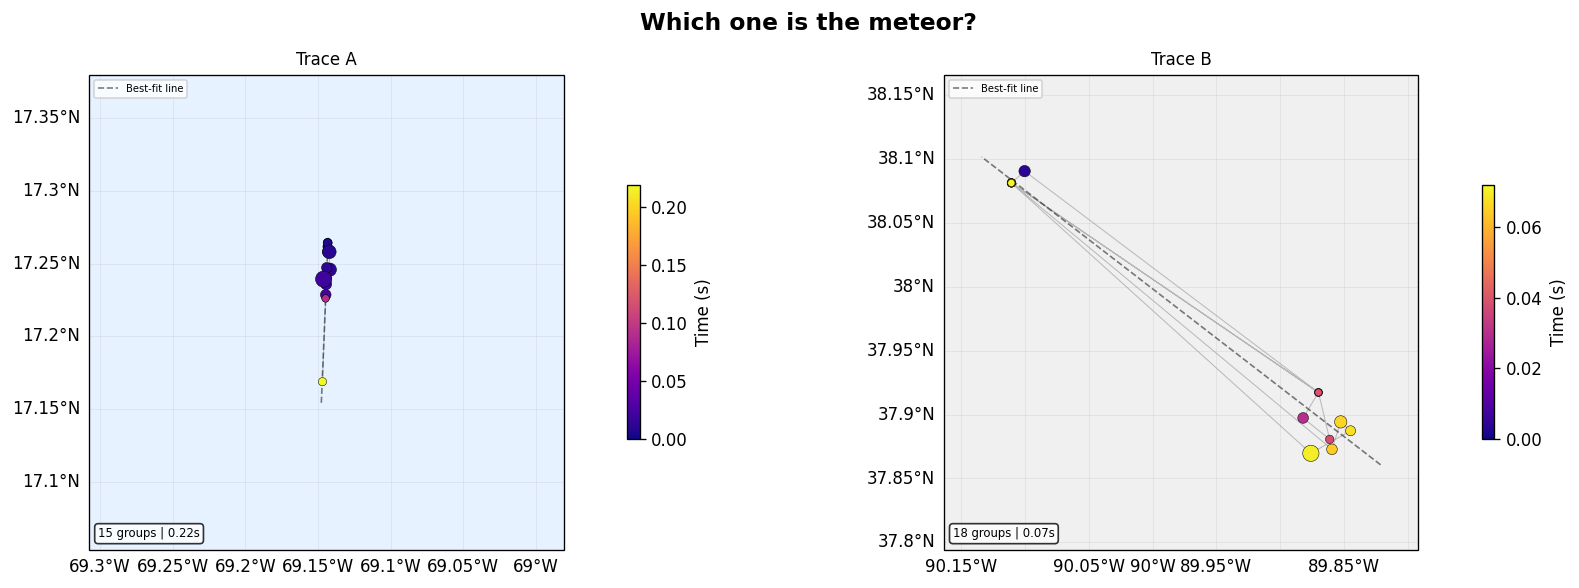

In [67]:
# side-by-side: which is the meteor?
imposters = [candidates[i]['df'] for i in range(min(3, len(candidates)))]
b_eids = list(bolide_data.keys())[:len(imposters)]

for i, eid in enumerate(b_eids):
    f = plt.figure(figsize=(16, 5.5))
    ax1 = f.add_subplot(1,2,1,projection=ccrs.PlateCarree())
    plot_trace(bolide_data[eid], ax1, title='Trace A', color='red')
    ax2 = f.add_subplot(1,2,2,projection=ccrs.PlateCarree())
    plot_trace(imposters[i], ax2, title='Trace B', color='steelblue')
    plt.subplots_adjust(top=0.88, wspace=0.35)
    f.suptitle('Which one is the meteor?', fontsize=14, fontweight='bold', y=0.95)
    plt.show()


**Reveal:** Trace A is the bolide, Trace B is lightning. The visual similarity motivates
the quantitative feature comparison that follows.


---
## 4. Lightning Controls


In [68]:
# extract lightning controls
lightning_features = []
lightning_clusters = {}
for _, row in catalog.iterrows():
    eid = row['eid']
    if eid not in bolide_data: continue
    dt = row['datetime'].to_pydatetime()
    n_ok = 0
    for off in CONTROL_OFFSETS_HR:
        cid = f'{eid}_ctrl{off:+d}h'
        feat, cdf = extract_control(dt + timedelta(hours=off), row['lat'], row['lon'])
        if feat is not None:
            feat['event_id']=eid; feat['label']='lightning'; feat['ctrl_id']=cid
            lightning_features.append(feat); lightning_clusters[cid]=cdf; n_ok+=1
    print(f'  {eid}: {n_ok}/5')
df_lightning = pd.DataFrame(lightning_features)
print(f'\nTotal: {len(df_lightning)} lightning samples')


  B000: 5/5
  B001: 2/5
  B002: 5/5
  B003: 5/5
  B004: 5/5
  B005: 5/5
  B006: 5/5
  B007: 4/5
  B008: 0/5
  B009: 5/5
  B010: 2/5
  B011: 5/5
  B012: 0/5
  B013: 0/5
  B014: 5/5
  B015: 0/5
  B016: 4/5
  B017: 5/5
  B018: 0/5
  B019: 2/5
  B020: 0/5
  B021: 2/5
  B022: 0/5
  B023: 4/5
  B024: 5/5
  B025: 5/5
  B026: 2/5
  B027: 0/5
  B028: 5/5
  B029: 5/5

Total: 92 lightning samples


In [69]:
# merge feature table
merge = FEATURE_COLS + ['event_id','label']
df_all = pd.concat([df_bolide[[c for c in merge if c in df_bolide.columns]],
                     df_lightning[[c for c in merge if c in df_lightning.columns]]],ignore_index=True)
print(f'Combined: {len(df_all)} (bolide: {(df_all["label"]=="bolide").sum()}, lightning: {(df_all["label"]=="lightning").sum()})')
df_all.to_csv('feature_table.csv', index=False)


Combined: 122 (bolide: 30, lightning: 92)


---
## 5. Feature Comparison


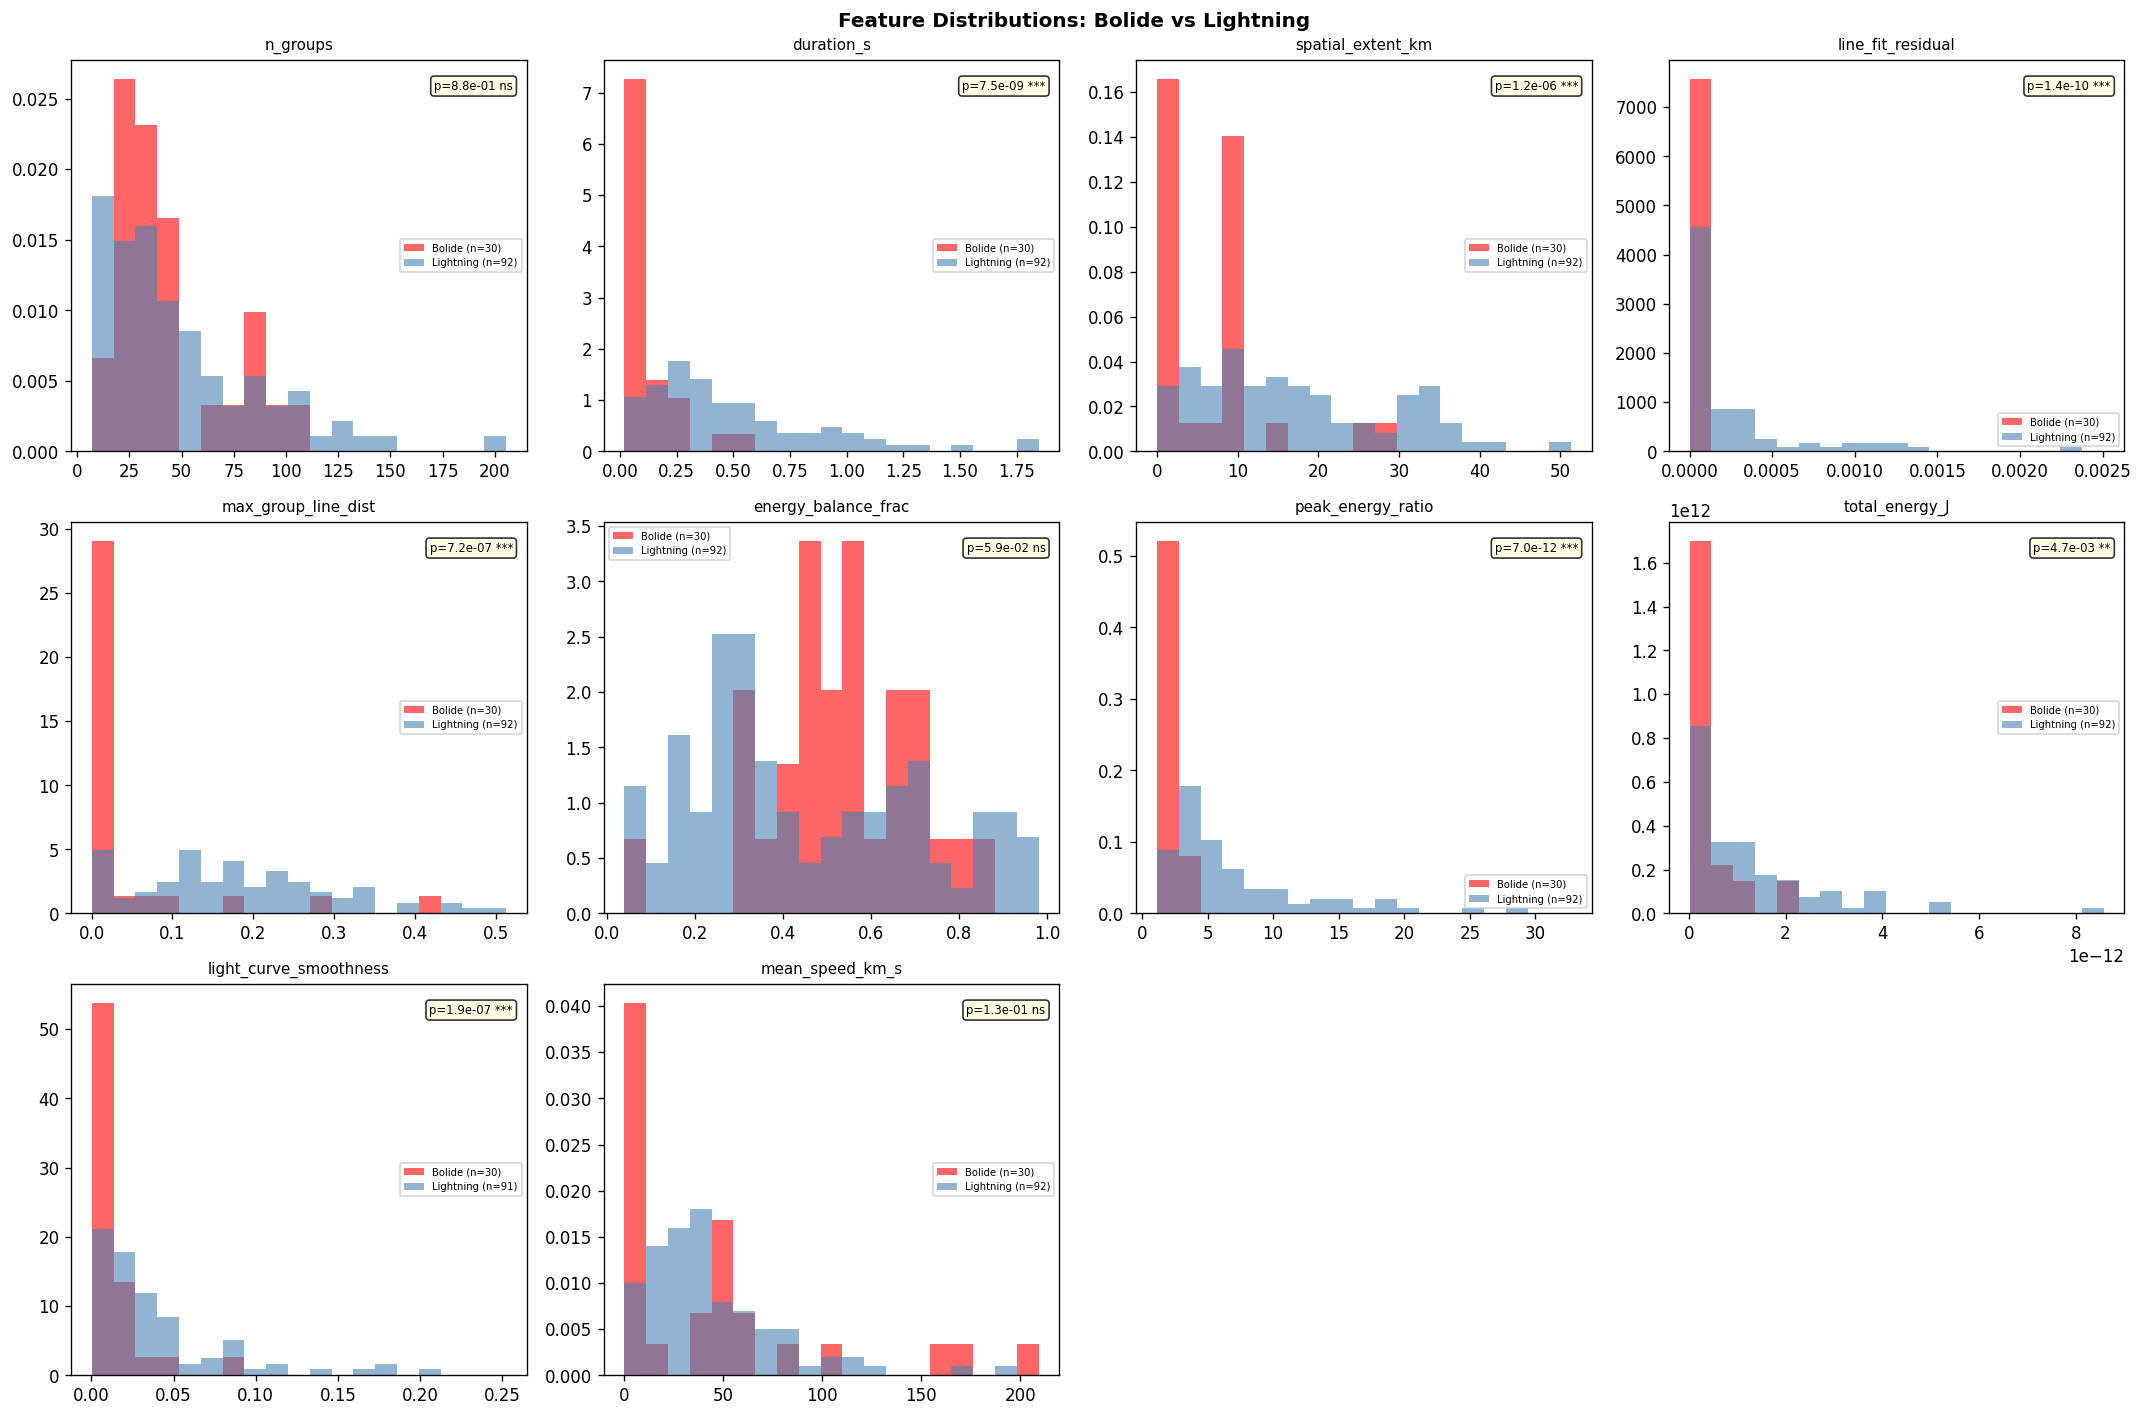

In [70]:
# histograms + Mann-Whitney U
bdata = df_all[df_all['label']=='bolide']; ldata = df_all[df_all['label']=='lightning']
f, axes = plt.subplots(3, 4, figsize=(18, 12))
mw_results = []
for i, feat in enumerate(FEATURE_COLS):
    ax = axes.flat[i]
    bv, lv = bdata[feat].dropna(), ldata[feat].dropna()
    bins = np.linspace(pd.concat([bv,lv]).quantile(0.01), pd.concat([bv,lv]).quantile(0.99), 20)
    ax.hist(bv, bins=bins, alpha=0.6, density=True, color='red', label=f'Bolide (n={len(bv)})')
    ax.hist(lv, bins=bins, alpha=0.6, density=True, color='steelblue', label=f'Lightning (n={len(lv)})')
    if len(bv)>=3 and len(lv)>=3:
        stat, pv = stats.mannwhitneyu(bv, lv, alternative='two-sided')
        sig = '***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'ns'
        ax.text(0.97,0.95,f'p={pv:.1e} {sig}',transform=ax.transAxes,ha='right',va='top',fontsize=7,
                bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8))
        mw_results.append({'feature':feat,'p_value':pv,'significant':sig})
    ax.set_title(feat, fontsize=9); ax.legend(fontsize=6)
for j in range(len(FEATURE_COLS), len(axes.flat)): axes.flat[j].set_visible(False)
f.suptitle('Feature Distributions: Bolide vs Lightning', fontweight='bold')
plt.tight_layout()


In [71]:
# summary table
df_mw = pd.DataFrame(mw_results).sort_values('p_value')
for _, r in df_mw.iterrows():
    f = r['feature']
    df_mw.loc[df_mw['feature']==f,'bolide_med'] = bdata[f].median()
    df_mw.loc[df_mw['feature']==f,'lightning_med'] = ldata[f].median()
df_mw[['feature','bolide_med','lightning_med','p_value','significant']]


,feature,bolide_med,lightning_med,p_value,significant
6,peak_energy_ratio,1.620169e+00,5.095615e+00,6.980314e-12,***
3,line_fit_residual,2.042132e-10,8.068603e-05,1.434815e-10,***
1,duration_s,7.572200e-02,3.797585e-01,7.514612e-09,***
8,light_curve_smoothness,1.900988e-03,2.634180e-02,1.917782e-07,***
4,max_group_line_dist,1.093964e-02,1.661167e-01,7.213754e-07,***
2,spatial_extent_km,6.062228e+00,1.441629e+01,1.171536e-06,***
7,total_energy_J,2.870933e-13,8.052570e-13,4.697846e-03,**
5,energy_balance_frac,5.419500e-01,3.711387e-01,5.906916e-02,ns
9,mean_speed_km_s,2.726977e+01,3.456477e+01,1.257820e-01,ns
0,n_groups,3.650000e+01,3.800000e+01,8.841700e-01,ns


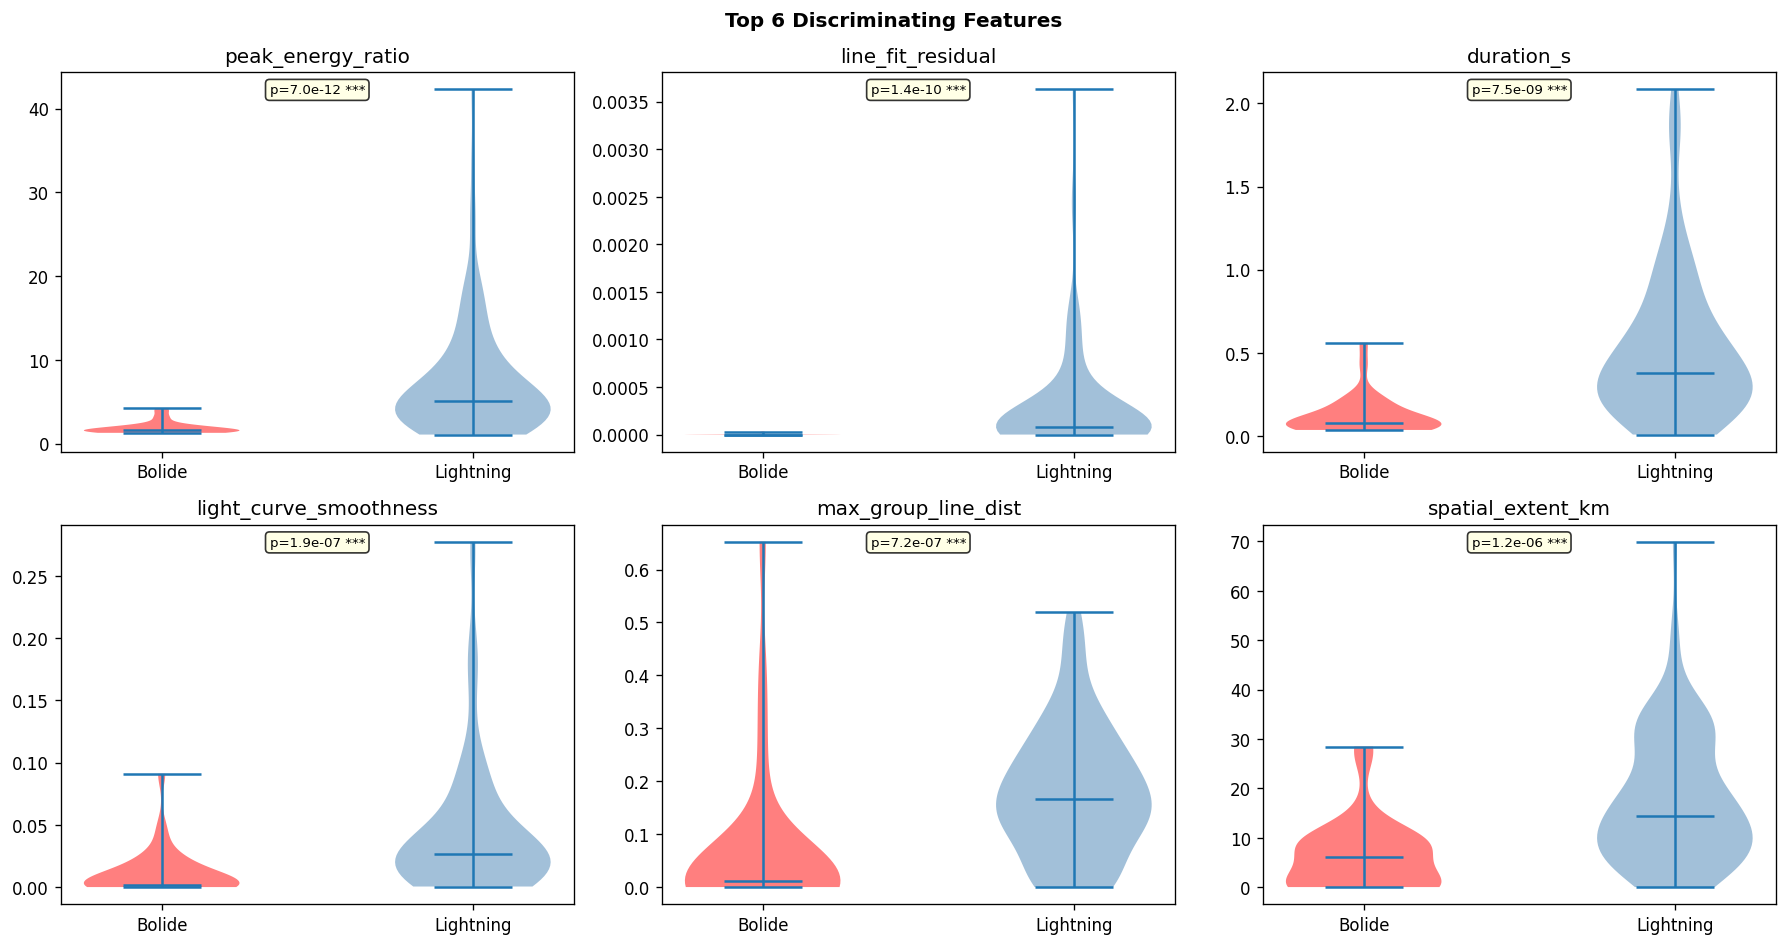

In [72]:
# violin plots for top 6
top6 = df_mw.head(6)['feature'].tolist()
f, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, top6):
    bv, lv = bdata[feat].dropna().values, ldata[feat].dropna().values
    parts = ax.violinplot([bv, lv], positions=[0,1], showmedians=True)
    for pc, col in zip(parts['bodies'], ['red','steelblue']): pc.set_facecolor(col); pc.set_alpha(0.5)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Bolide','Lightning'])
    ax.set_title(feat)
    pv = df_mw[df_mw['feature']==feat]['p_value'].values[0]
    sig = df_mw[df_mw['feature']==feat]['significant'].values[0]
    ax.text(0.5,0.97,f'p={pv:.1e} {sig}',transform=ax.transAxes,ha='center',va='top',fontsize=8,
            bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8))
f.suptitle('Top 6 Discriminating Features', fontweight='bold')
plt.tight_layout()


---
## 6. PCA


Variance: PC1=41.0%, PC2=13.1%


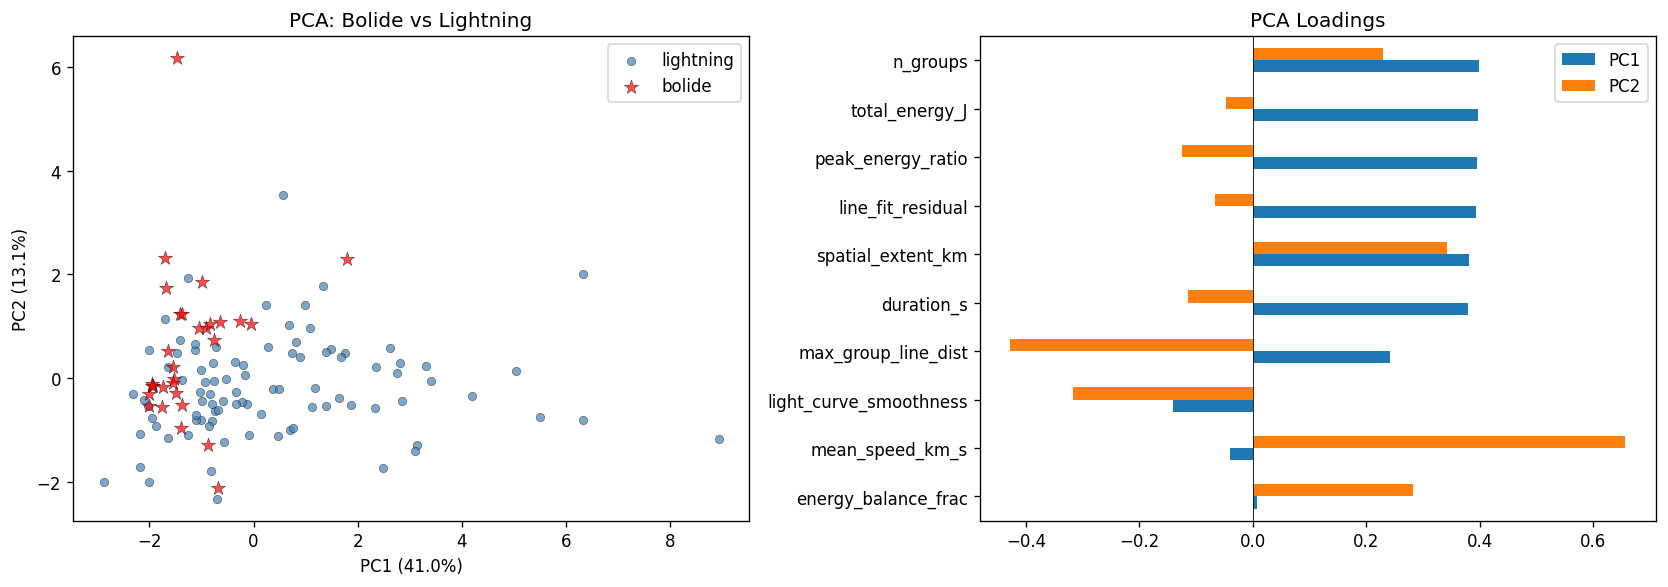

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df_pca = df_all[FEATURE_COLS+['label']].dropna()
X = StandardScaler().fit_transform(df_pca[FEATURE_COLS].values)
labels = df_pca['label'].values
pca = PCA(n_components=2); Xp = pca.fit_transform(X)

f, axes = plt.subplots(1, 2, figsize=(14, 5))
for lb, c, m, s in [('lightning','steelblue','o',25),('bolide','red','*',80)]:
    mask = labels==lb
    axes[0].scatter(Xp[mask,0], Xp[mask,1], c=c, marker=m, s=s, alpha=0.7, label=lb, edgecolors='k', linewidths=0.3)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA: Bolide vs Lightning'); axes[0].legend()

ld = pd.DataFrame(pca.components_.T, index=FEATURE_COLS, columns=['PC1','PC2'])
ld.reindex(ld['PC1'].abs().sort_values(ascending=True).index).plot.barh(ax=axes[1])
axes[1].set_title('PCA Loadings'); axes[1].axvline(0, color='k', lw=0.5)
plt.tight_layout()
print(f'Variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')


---
## 7. Global Map


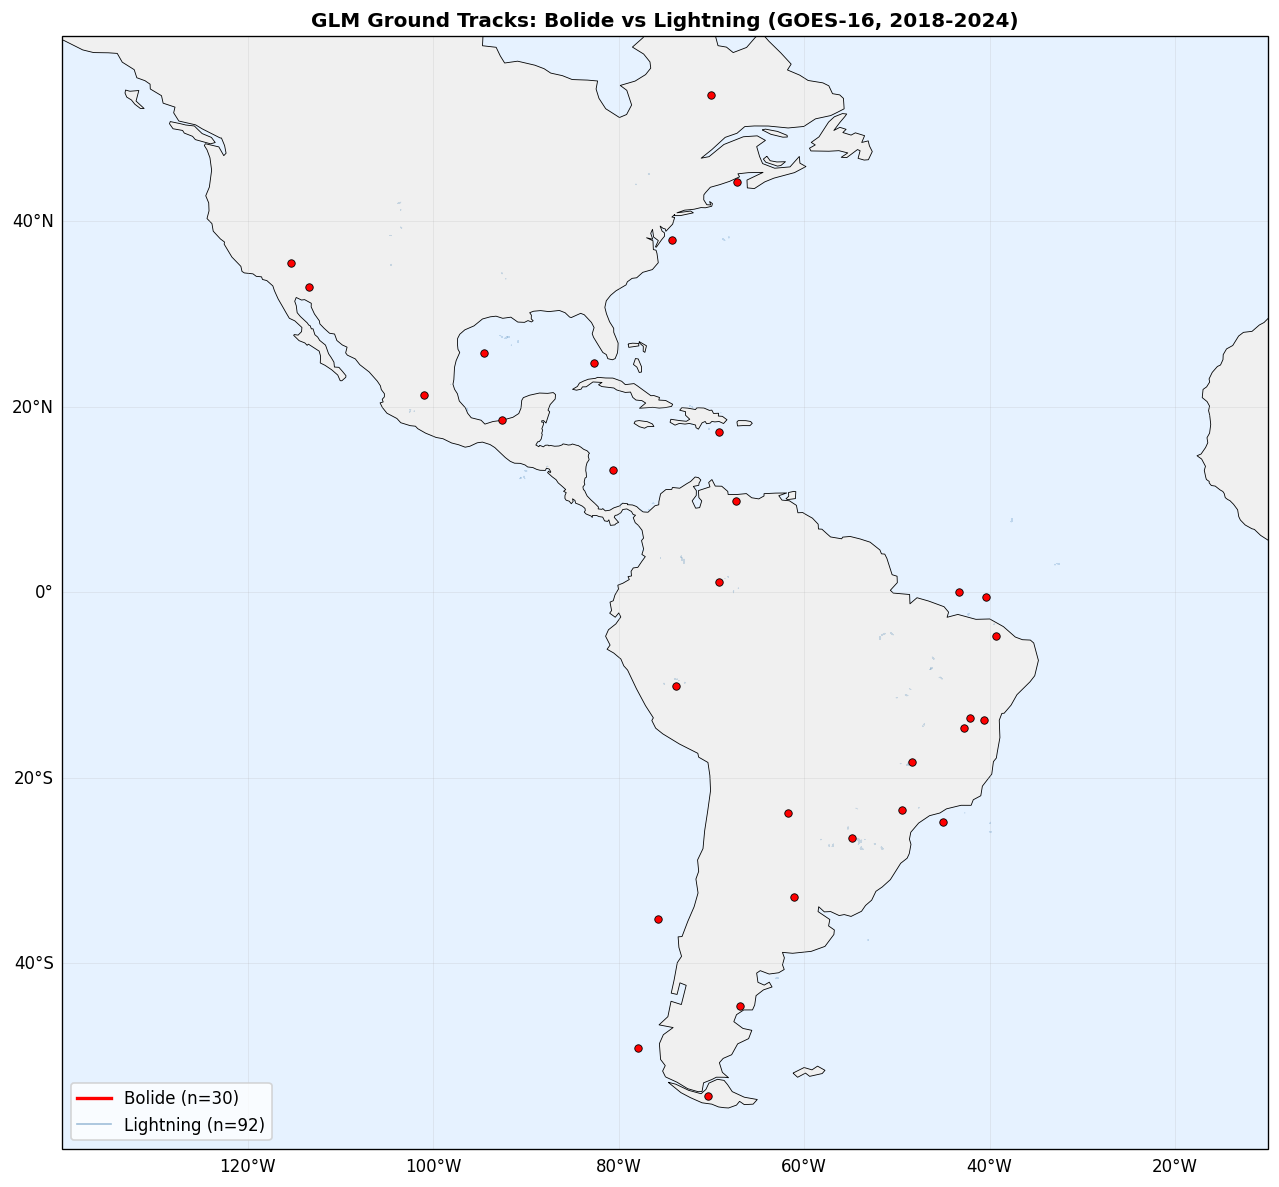

In [74]:
f = plt.figure(figsize=(14, 10))
ax = f.add_subplot(1,1,1,projection=ccrs.PlateCarree())
ax.set_extent([-140,-10,-60,60],crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f2ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels={'left':True,'bottom':True,'right':False,'top':False}, linewidth=0.3, alpha=0.4)

nl=0
for cid, ldf in lightning_clusters.items():
    if ldf is not None and len(ldf)>=3:
        ls=ldf.sort_values('time')
        ax.plot(ls['lon'].values,ls['lat'].values,'-',color='steelblue',lw=0.5,alpha=0.25,transform=ccrs.PlateCarree())
        nl+=1
nb=0
for eid, bdf in bolide_data.items():
    bs=bdf.sort_values('time')
    ax.plot(bs['lon'].values,bs['lat'].values,'-',color='red',lw=1.5,alpha=0.8,transform=ccrs.PlateCarree())
    ax.scatter(bs['lon'].iloc[0],bs['lat'].iloc[0],s=20,color='red',edgecolors='k',linewidths=0.5,transform=ccrs.PlateCarree(),zorder=10)
    nb+=1

from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],color='red',lw=2,label=f'Bolide (n={nb})'),
                    Line2D([0],[0],color='steelblue',lw=1,alpha=0.5,label=f'Lightning (n={nl})')],
          loc='lower left', fontsize=10)
ax.set_title('GLM Ground Tracks: Bolide vs Lightning (GOES-16, 2018-2024)', fontweight='bold')
plt.tight_layout()


---
## 8. Case Studies


In [75]:
# select events with controls
events_with_ctrl = set(cid.split('_ctrl')[0] for cid in lightning_clusters if lightning_clusters[cid] is not None and len(lightning_clusters[cid])>=5)
case_eids = []
for tier in ['high','mid','low']:
    te = catalog[(catalog['energy_tier']==tier)&(catalog['eid'].isin(events_with_ctrl))&(catalog['eid'].isin(bolide_data))]
    te = te[te['eid'].apply(lambda e: len(bolide_data.get(e,[]))>=20)]
    for _, r in te.head(2).iterrows(): case_eids.append(r['eid'])
case_eids = case_eids[:5]
print(f'Case studies: {case_eids}')


Case studies: ['B001', 'B004', 'B003', 'B006', 'B014']


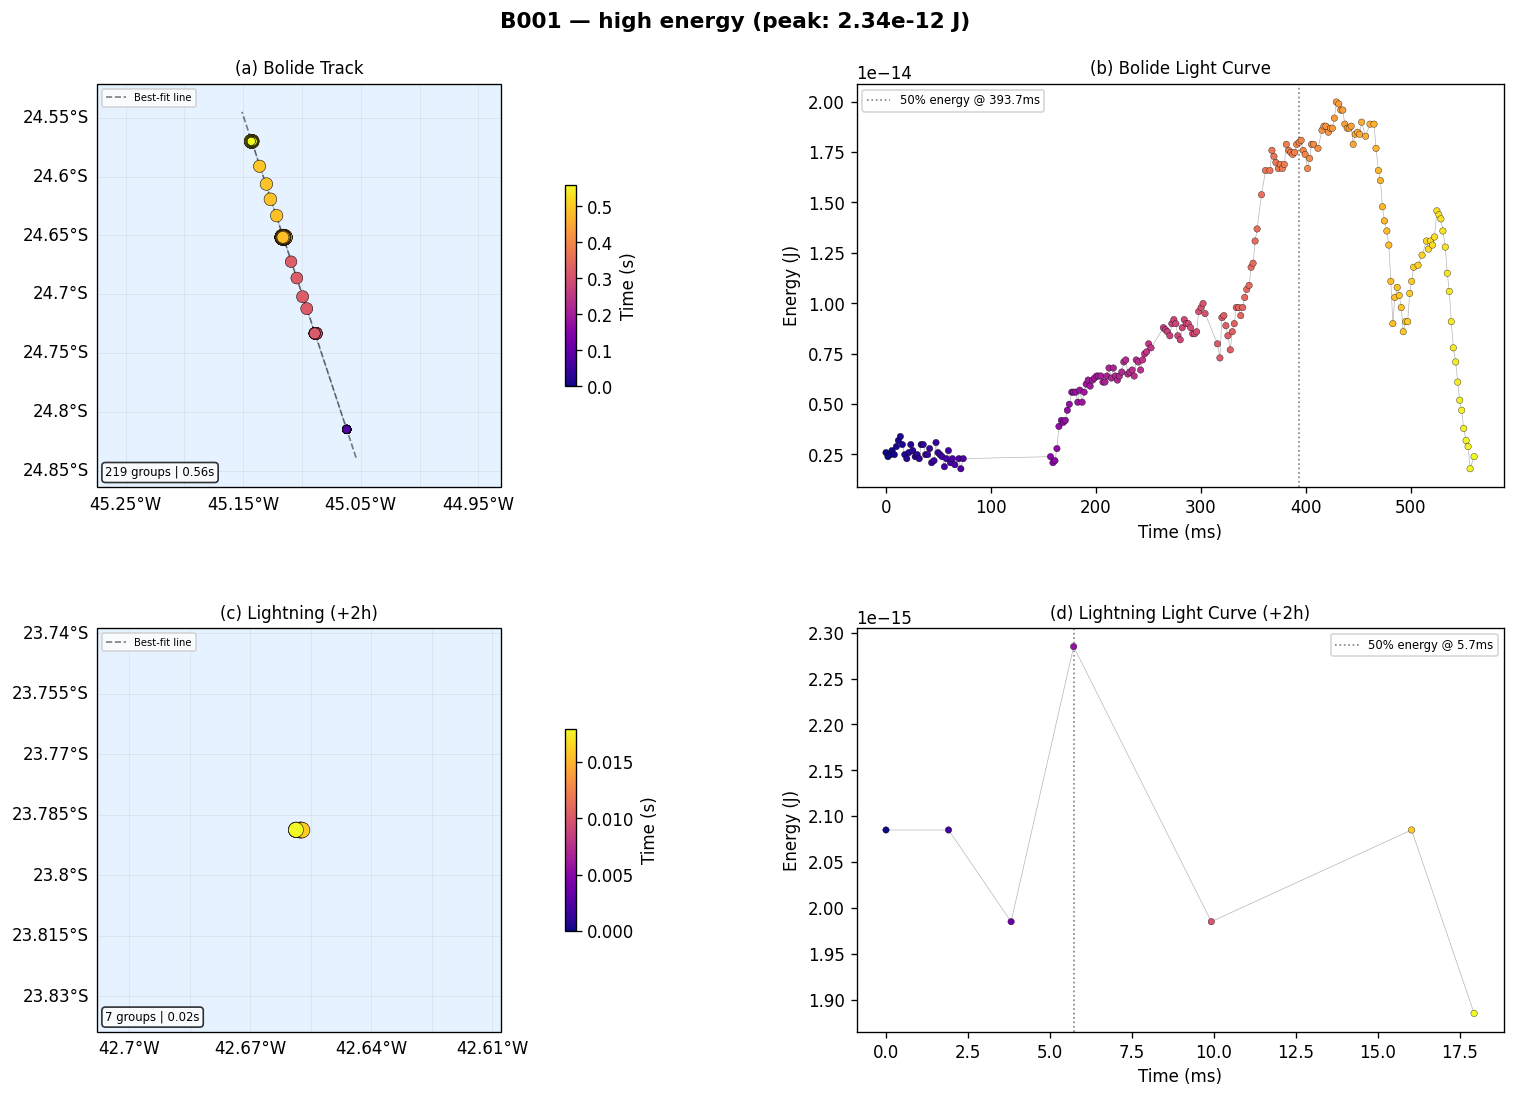

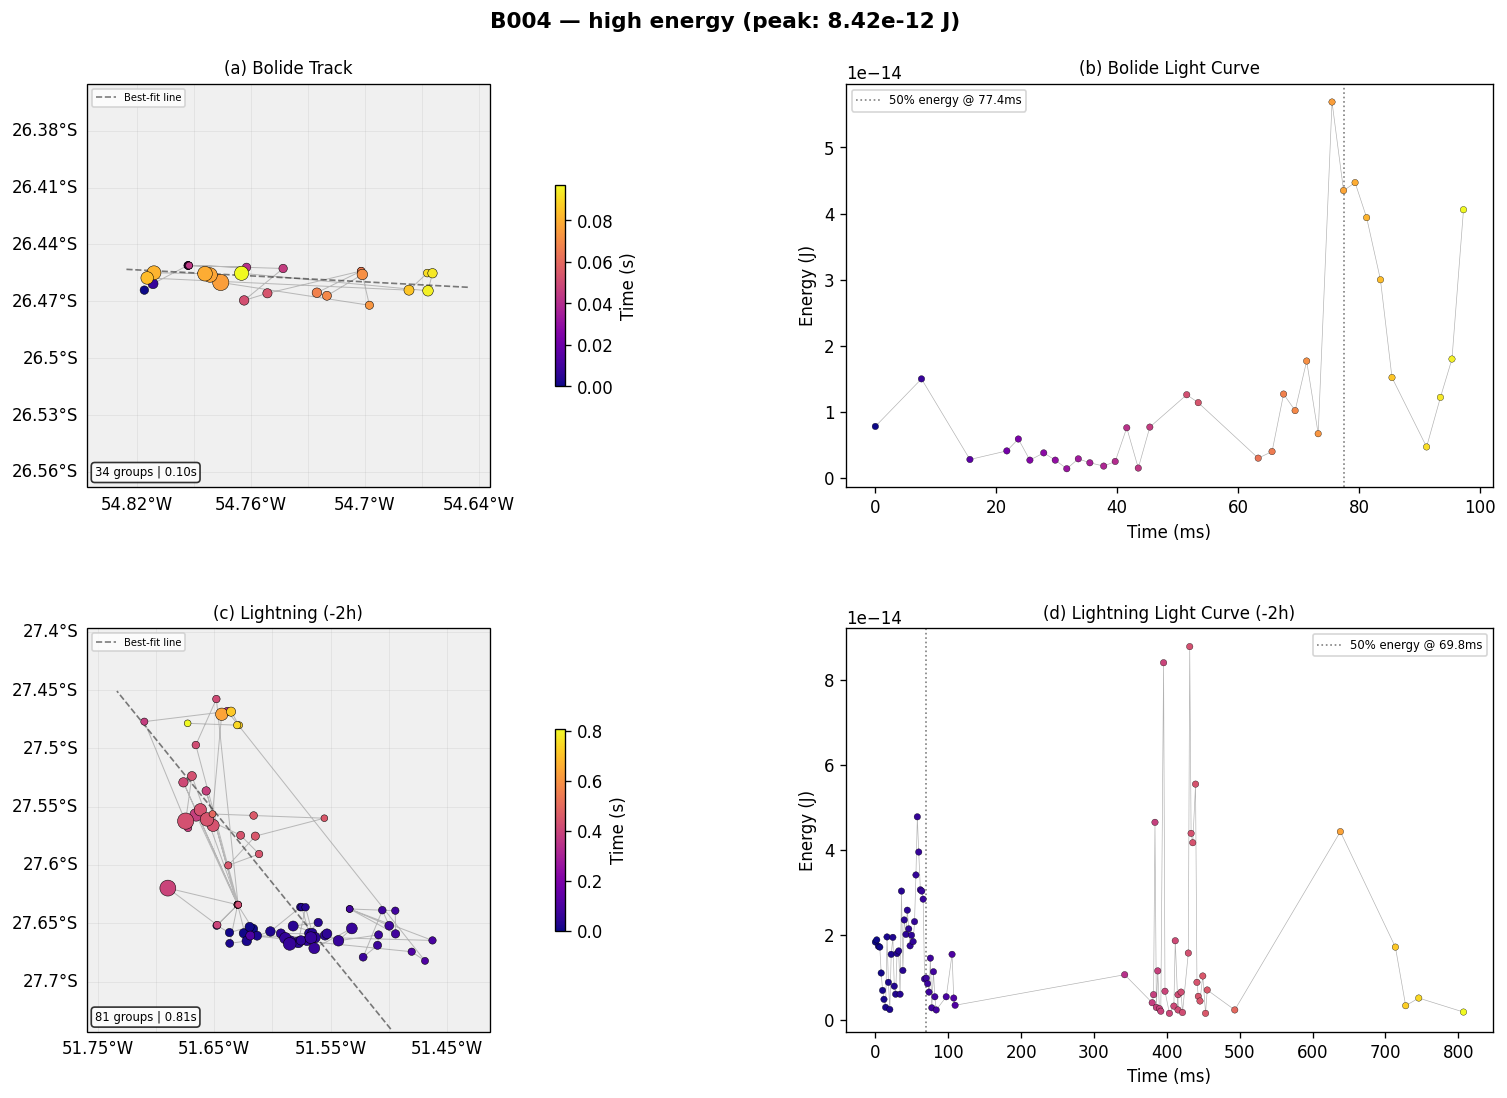

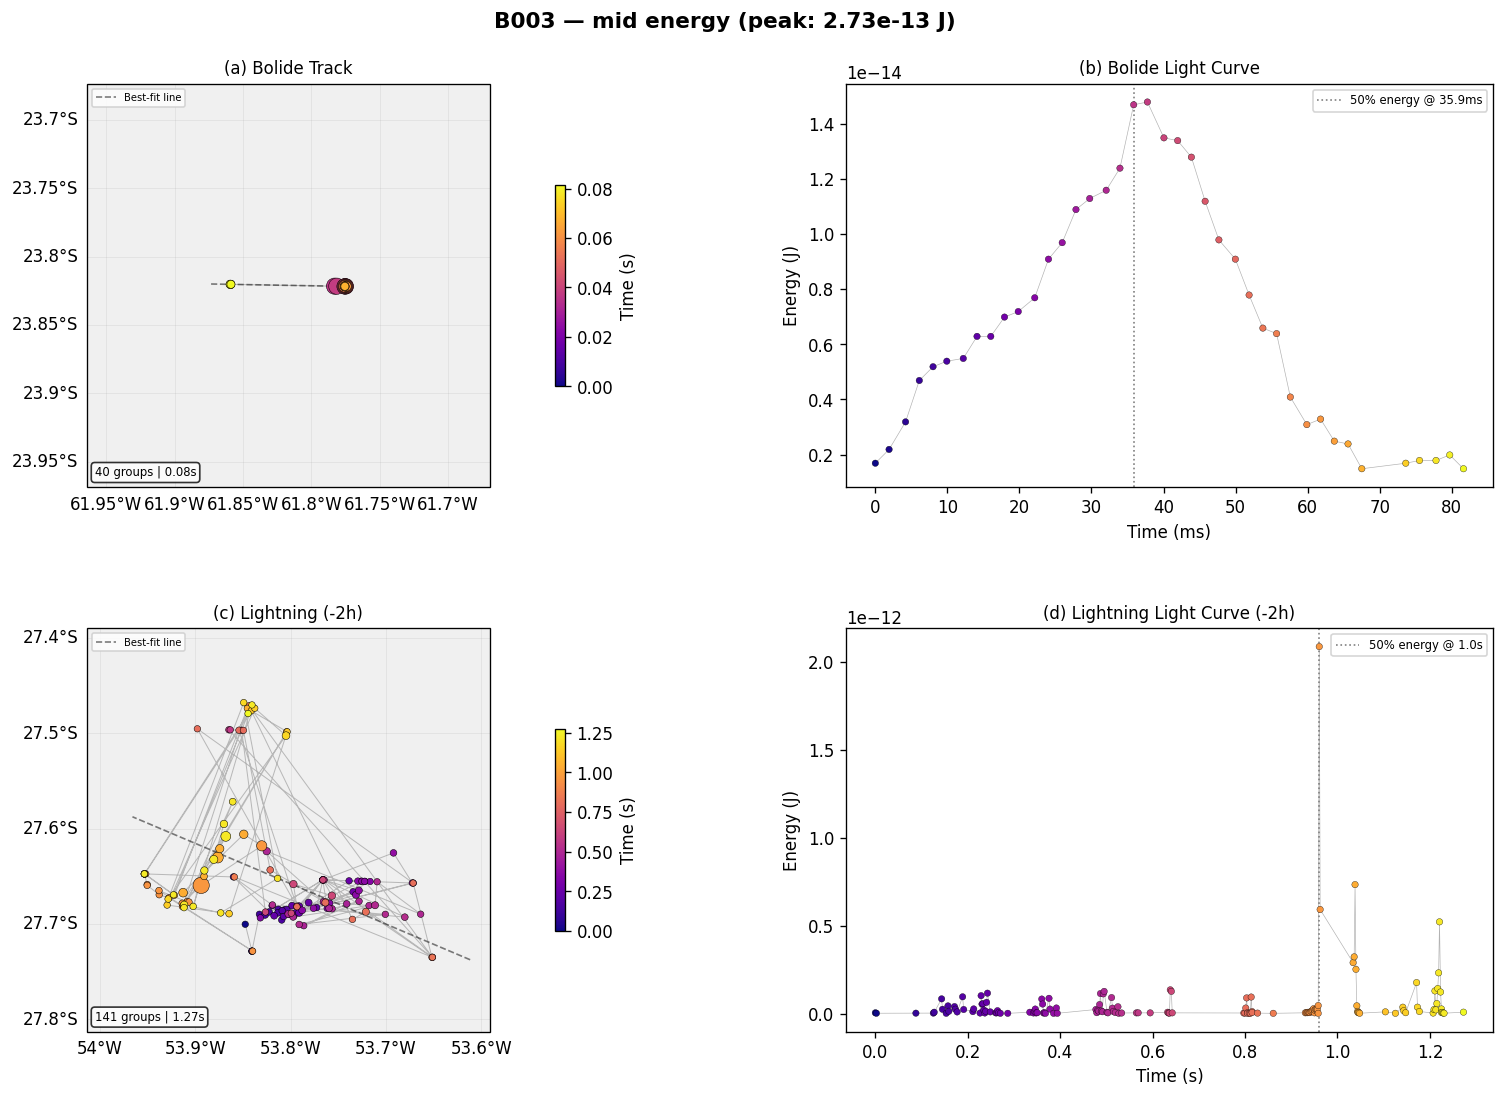

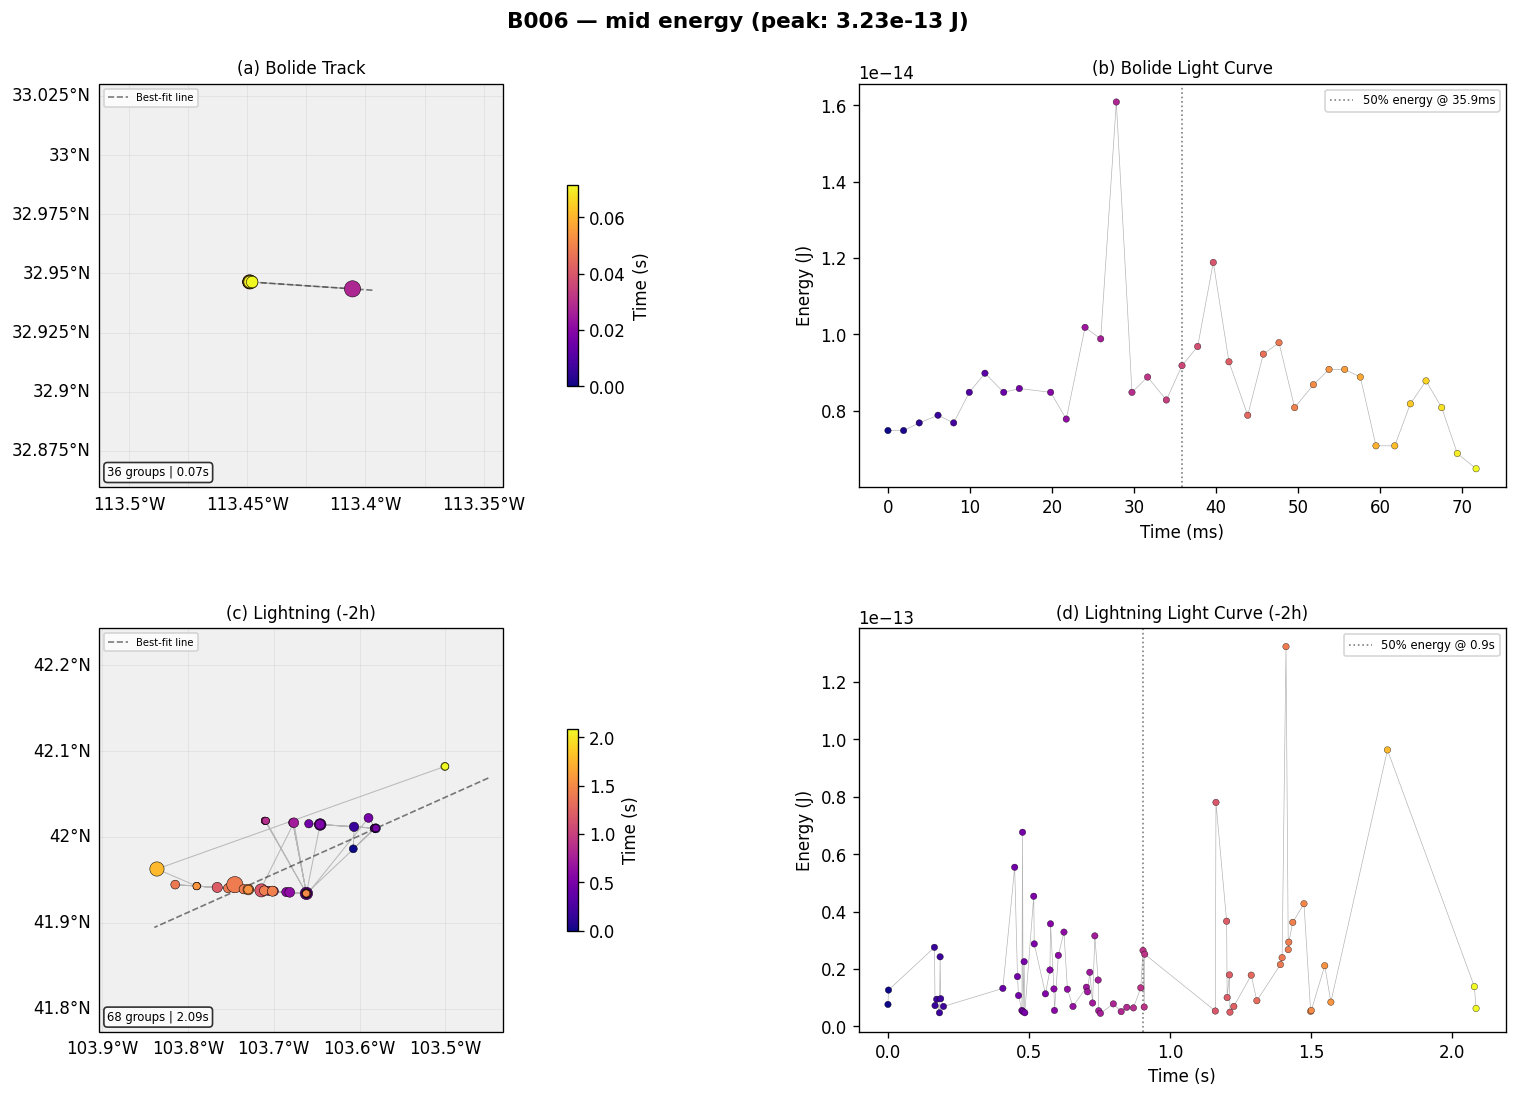

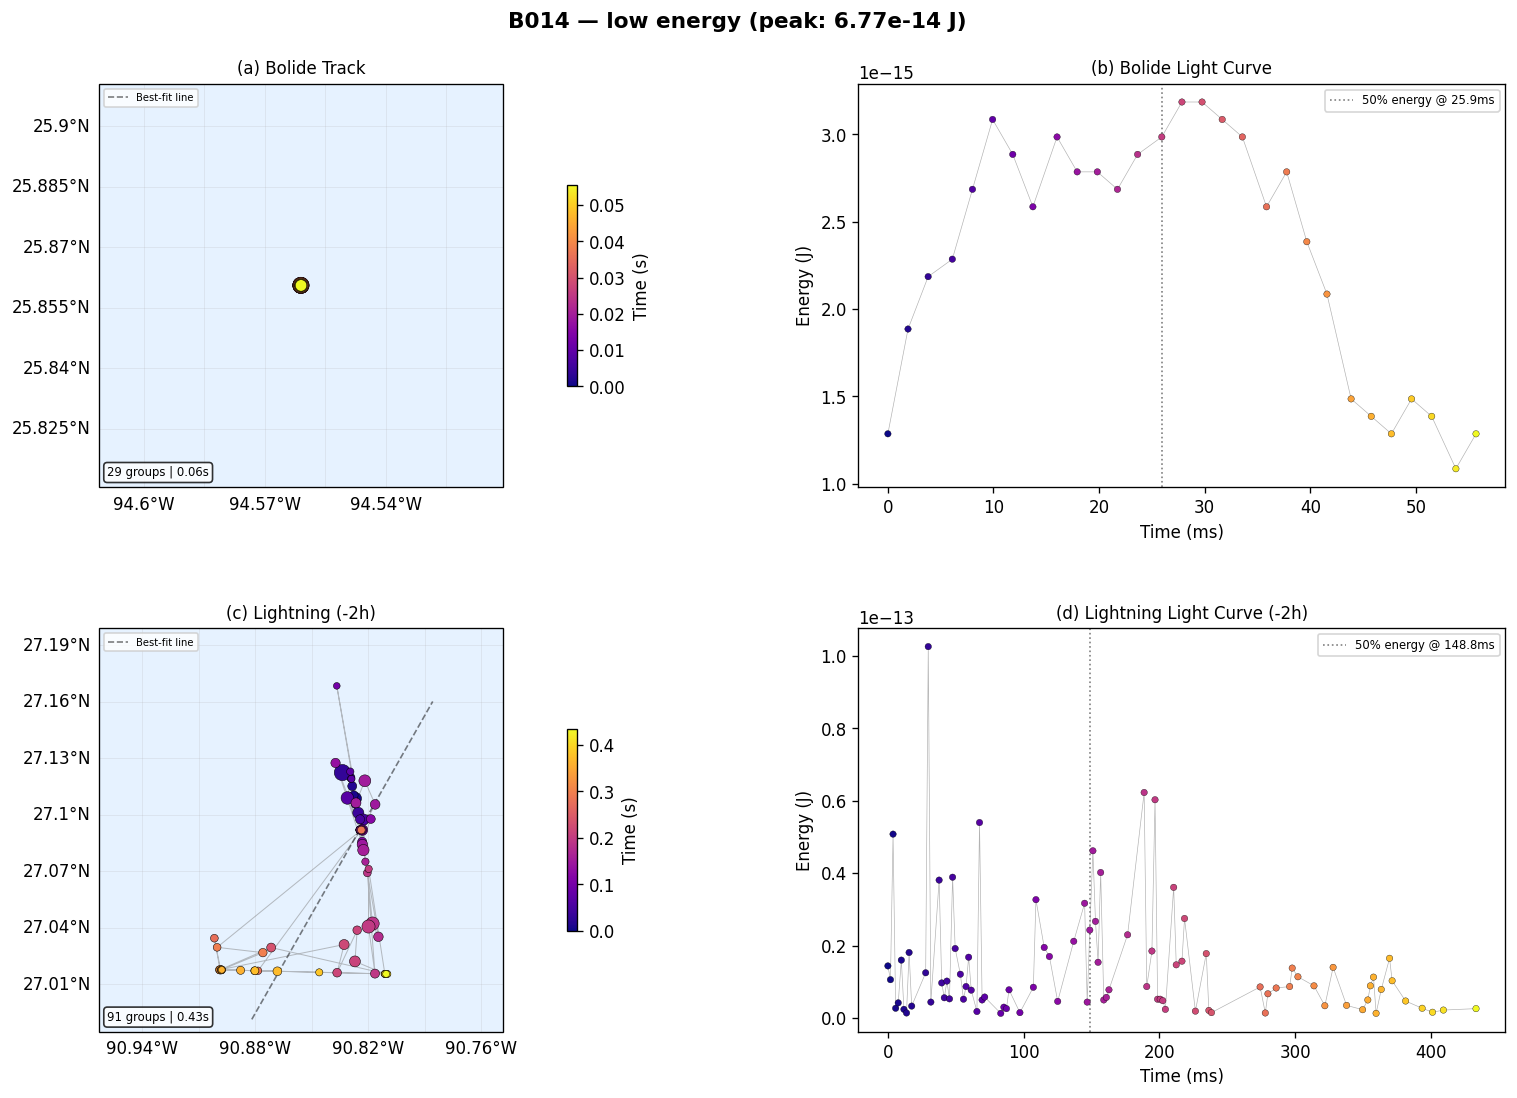

In [76]:
for eid in case_eids:
    row = catalog[catalog['eid']==eid].iloc[0]
    bdf = bolide_data[eid]
    ldf = None; clbl = ''
    for off in CONTROL_OFFSETS_HR:
        cid = f'{eid}_ctrl{off:+d}h'
        if cid in lightning_clusters and lightning_clusters[cid] is not None and len(lightning_clusters[cid])>=5:
            ldf=lightning_clusters[cid]; clbl=f'{off:+d}h'; break
    bf = df_bolide[df_bolide['event_id']==eid]
    bf = bf.iloc[0] if len(bf)>0 else None
    
    fig = plt.figure(figsize=(16, 10))
    ax_a = fig.add_subplot(2,2,1,projection=ccrs.PlateCarree())
    plot_trace(bdf, ax_a, title='(a) Bolide Track', color='red')
    ax_b = fig.add_subplot(2,2,2)
    plot_lightcurve(bdf, ax_b, title='(b) Bolide Light Curve')
    ax_c = fig.add_subplot(2,2,3,projection=ccrs.PlateCarree())
    if ldf is not None:
        plot_trace(ldf, ax_c, title=f'(c) Lightning ({clbl})', color='steelblue')
    else:
        ax_c.text(0.5,0.5,'No control',ha='center',va='center',transform=ax_c.transAxes)
    ax_d = fig.add_subplot(2,2,4)
    if ldf is not None:
        plot_lightcurve(ldf, ax_d, title=f'(d) Lightning Light Curve ({clbl})')
    else:
        ax_d.text(0.5,0.5,'N/A',ha='center',va='center',transform=ax_d.transAxes)
    plt.subplots_adjust(top=0.90, hspace=0.35, wspace=0.3)
    fig.suptitle(f'{eid} — {row["energy_tier"]} energy (peak: {row["peak_energy"]:.2e} J)',
                 fontsize=13, fontweight='bold', y=0.96)
    plt.show()


---
## 9. Summary


In [77]:
# summary
print('RESULTS SUMMARY')
print('='*65)
print(f'Bolide events: {len(df_bolide)}')
print(f'Lightning controls: {len(df_lightning)}')
print()

print('Feature discriminability (Mann-Whitney U):')
print('-'*65)
for _, r in df_mw.iterrows():
    d = 'higher' if r['bolide_med'] > r['lightning_med'] else 'lower'
    print(f"  {r['feature']:30s} p={r['p_value']:.2e} {r['significant']:4s} bolide {d}")

sig = df_mw[df_mw['significant'].isin(['***','**','*'])]['feature'].tolist()
ns = df_mw[df_mw['significant']=='ns']['feature'].tolist()
print(f'\nSignificant ({len(sig)}): {", ".join(sig)}')
print(f'Non-significant ({len(ns)}): {", ".join(ns)}')
print(f'\nPCA: {sum(pca.explained_variance_ratio_[:2]):.1%} variance in 2 components')


RESULTS SUMMARY
Bolide events: 30
Lightning controls: 92

Feature discriminability (Mann-Whitney U):
-----------------------------------------------------------------
  peak_energy_ratio              p=6.98e-12 ***  bolide lower
  line_fit_residual              p=1.43e-10 ***  bolide lower
  duration_s                     p=7.51e-09 ***  bolide lower
  light_curve_smoothness         p=1.92e-07 ***  bolide lower
  max_group_line_dist            p=7.21e-07 ***  bolide lower
  spatial_extent_km              p=1.17e-06 ***  bolide lower
  total_energy_J                 p=4.70e-03 **   bolide lower
  energy_balance_frac            p=5.91e-02 ns   bolide higher
  mean_speed_km_s                p=1.26e-01 ns   bolide lower
  n_groups                       p=8.84e-01 ns   bolide lower

Significant (7): peak_energy_ratio, line_fit_residual, duration_s, light_curve_smoothness, max_group_line_dist, spatial_extent_km, total_energy_J
Non-significant (3): energy_balance_frac, mean_speed_km_s, n_grou